In [1]:
import sys
sys.path.append("../../../")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from LRM.CMP1D import SmoothedEmpiricalDensity1D, CMP1D
from LRM.minimax_tilting_sampler import TruncatedMVN

from LRM.plotting import set_plot_style
set_plot_style()

In [2]:
def lrm_truncated_gaussian_posterior(Lambda, nu, beta, prior="uniform", **prior_kwargs):
    """
    Builds the closed-form truncated Gaussian posterior for CMP1D LRM-Bayes.

    The LRM term is

        exp{- beta theta^T Lambda theta + 2 beta nu^T theta}.

    The priors considered here all have the form

        pi(theta) ∝ exp{eta^T theta} 1{lb < theta < ub}.

    Therefore,

        posterior(theta) ∝ exp{
            - beta theta^T Lambda theta
            + (2 beta nu + eta)^T theta
        } 1{lb < theta < ub}.

    So the untruncated Gaussian has

        precision = 2 beta Lambda,
        Sigma = precision^{-1},
        mu = Sigma @ (2 beta nu + eta).
    """

    Lambda = np.asarray(Lambda, dtype=float)
    nu = np.asarray(nu, dtype=float).reshape(-1)

    d = Lambda.shape[0]

    if prior == "uniform":
        lb = np.asarray(prior_kwargs.get("lb", -10 * np.ones(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub",  10 * np.ones(d)), dtype=float)
        eta = np.zeros(d)

    elif prior == "exponential":
        rates = np.asarray(prior_kwargs.get("rates", np.ones(d)), dtype=float)

        if np.any(rates <= 0):
            raise ValueError("Exponential rates must be positive.")

        lb = np.asarray(prior_kwargs.get("lb", np.zeros(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub", np.inf * np.ones(d)), dtype=float)
        eta = -rates

    elif prior == "continuous bernoulli":
        lam = np.asarray(prior_kwargs.get("lam", 0.5 * np.ones(d)), dtype=float)

        if np.any(lam <= 0) or np.any(lam >= 1):
            raise ValueError("Continuous-Bernoulli lambda values must be in (0, 1).")

        lb = np.asarray(prior_kwargs.get("lb", np.zeros(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub", np.ones(d)), dtype=float)
        eta = np.log(lam / (1.0 - lam))

    else:
        raise ValueError(f"Unknown prior: {prior}")

    # Numerical symmetry / stability.
    precision = 2.0 * beta * Lambda
    precision = 0.5 * (precision + precision.T)

    eig_min = np.min(np.linalg.eigvalsh(precision))
    if eig_min <= 1e-10:
        precision = precision + (1e-10 - eig_min + 1e-10) * np.eye(d)

    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (2.0 * beta * nu + eta)

    post = TruncatedMVN(
        mu=mu,
        cov=Sigma,
        lb=lb,
        ub=ub,
    )

    return post, mu, Sigma

In [3]:
def run_cmp1d_lrm_priors(
    data,
    beta,
    alpha=1.0,
    cutoff=-1e10,
    prior_specs=None,
    n_samples=20_000,
):
    """
    Research-code version:
    - fits the smoothed empirical PMF,
    - builds the CMP1D LRM matrices,
    - samples from each closed-form truncated Gaussian posterior.
    """

    data = np.asarray(data).ravel().astype(int)

    if prior_specs is None:
        prior_specs = [
            {
                "name": "uniform",
                "prior": "uniform",
                "kwargs": {
                    "lb": [-10.0, -10.0],
                    "ub": [10.0, 10.0],
                },
            },
            {
                "name": "exponential",
                "prior": "exponential",
                "kwargs": {
                    "rates": [1.0, 1.0],
                },
            },
            {
                "name": "continuous bernoulli",
                "prior": "continuous bernoulli",
                "kwargs": {
                    "lam": [0.5, 0.5],
                },
            },
        ]

    empirical = SmoothedEmpiricalDensity1D(alpha=alpha).fit(data)
    model = CMP1D(empirical=empirical, cutoff=cutoff)

    Lambda, nu, ignored = model._Lambda_nu(data)
    nu = np.asarray(nu).reshape(-1)

    results = {}

    for spec in tqdm(prior_specs):
        name = spec["name"]

        post, mu, Sigma = lrm_truncated_gaussian_posterior(
            Lambda=Lambda,
            nu=nu,
            beta=beta,
            prior=spec["prior"],
            **spec.get("kwargs", {}),
        )

        # TruncatedMVN returns shape (d, n), so transpose to (n, d).
        samples = post.sample(n_samples).T

        results[name] = {
            "samples": samples,
            "post": post,
            "mu_untruncated": mu,
            "Sigma_untruncated": Sigma,
            "mean": samples.mean(axis=0),
            "median": np.median(samples, axis=0),
            "ci_95": np.quantile(samples, [0.025, 0.975], axis=0),
        }

    return results, model, Lambda, nu, ignored

In [25]:
theta1, theta2 = 4.0, 1.25
i = 0
beta_lrm = 1
n_samples = 100
data = np.load(f"./outputs/dataset{i}_theta1={theta1}_theta2={theta2}.npy").flatten().ravel().astype(int)
data = np.random.choice(data, size=n_samples, replace=False)
len(data)

100

In [30]:
prior_specs = [
    {
        "name": "uniform",
        "prior": "uniform",
        "kwargs": {
            "lb": [np.log(2.0), 0.5],
            "ub": [np.log(6.0), 2.0],
        },
    },
    {
        "name": "exponential",
        "prior": "exponential",
        "kwargs": {
            "rates": [2.0, 2.0],
        },
    },
    {
        "name": "continuous bernoulli",
        "prior": "continuous bernoulli",
        "kwargs": {
            "lam": [0.5, 0.5],
            "lb": [np.log(1e-6), 0.0],
            "ub": [np.log(10.0), 10.0],
        },
    },
]

In [31]:
results, model, Lambda, nu, ignored = run_cmp1d_lrm_priors(
    data=data,
    beta=beta_lrm,
    alpha=1.0,
    cutoff=-1e10,
    prior_specs=prior_specs,
    n_samples=20_000,
)

  0%|          | 0/3 [00:00<?, ?it/s]

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def eta_to_theta_cmp1d(samples):
    """
    Transform CMP1D samples from eta-space to theta-space.

    Assumed parameterisation:

        eta_1 = log(theta_1),
        eta_2 = theta_2.

    Therefore the inverse transform is:

        theta_1 = exp(eta_1),
        theta_2 = eta_2.

    Parameters
    ----------
    samples : array-like, shape (n_samples, 2)
        Samples in eta-space.

    Returns
    -------
    theta : ndarray, shape (n_samples, 2)
        Samples in theta-space.
    """
    samples = np.asarray(samples, dtype=float)

    if samples.ndim != 2 or samples.shape[1] != 2:
        raise ValueError("Expected samples with shape (n_samples, 2).")

    theta = samples.copy()
    theta[:, 0] = np.exp(samples[:, 0])
    theta[:, 1] = samples[:, 1]

    return theta


def plot_cmp1d_lrm_prior_samples(
    results,
    thin=20,
    transform=eta_to_theta_cmp1d,
    true_theta=None,
    figsize=(5.5, 4.5),
):
    """
    Plot samples from the output of run_cmp1d_lrm_priors.

    results is the first returned object:

        results, model, Lambda, nu, ignored = run_cmp1d_lrm_priors(...)

    Parameters
    ----------
    results : dict
        Dictionary with entries results[prior_name]["samples"].

    thin : int
        Plot every `thin`-th sample.

    transform : callable or None
        Transform applied to samples before plotting.

        Default is eta_to_theta_cmp1d, corresponding to

            eta_1 = log(theta_1),
            eta_2 = theta_2.

        Set transform=None only if samples are already in theta-space.

    true_theta : tuple or None
        Optional true value in theta-space, e.g. true_theta=(4.0, 1.25).

    figsize : tuple
        Matplotlib figure size.
    """

    fig, ax = plt.subplots(figsize=figsize)

    for prior_name, out in results.items():
        samples = np.asarray(out["samples"], dtype=float)

        if transform is not None:
            samples = transform(samples)

        ax.scatter(
            samples[::thin, 0],
            samples[::thin, 1],
            s=2,
            alpha=0.5,
            label=prior_name,
        )

    if true_theta is not None:
        ax.axvline(
            true_theta[0],
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
        )
        ax.axhline(
            true_theta[1],
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
        )

    ax.set_xlabel(r"$\theta_1$", fontsize=16)
    ax.set_ylabel(r"$\theta_2$", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    ax.legend(frameon=False, fontsize=12, handletextpad=0.25, markerscale=4)

    plt.tight_layout()

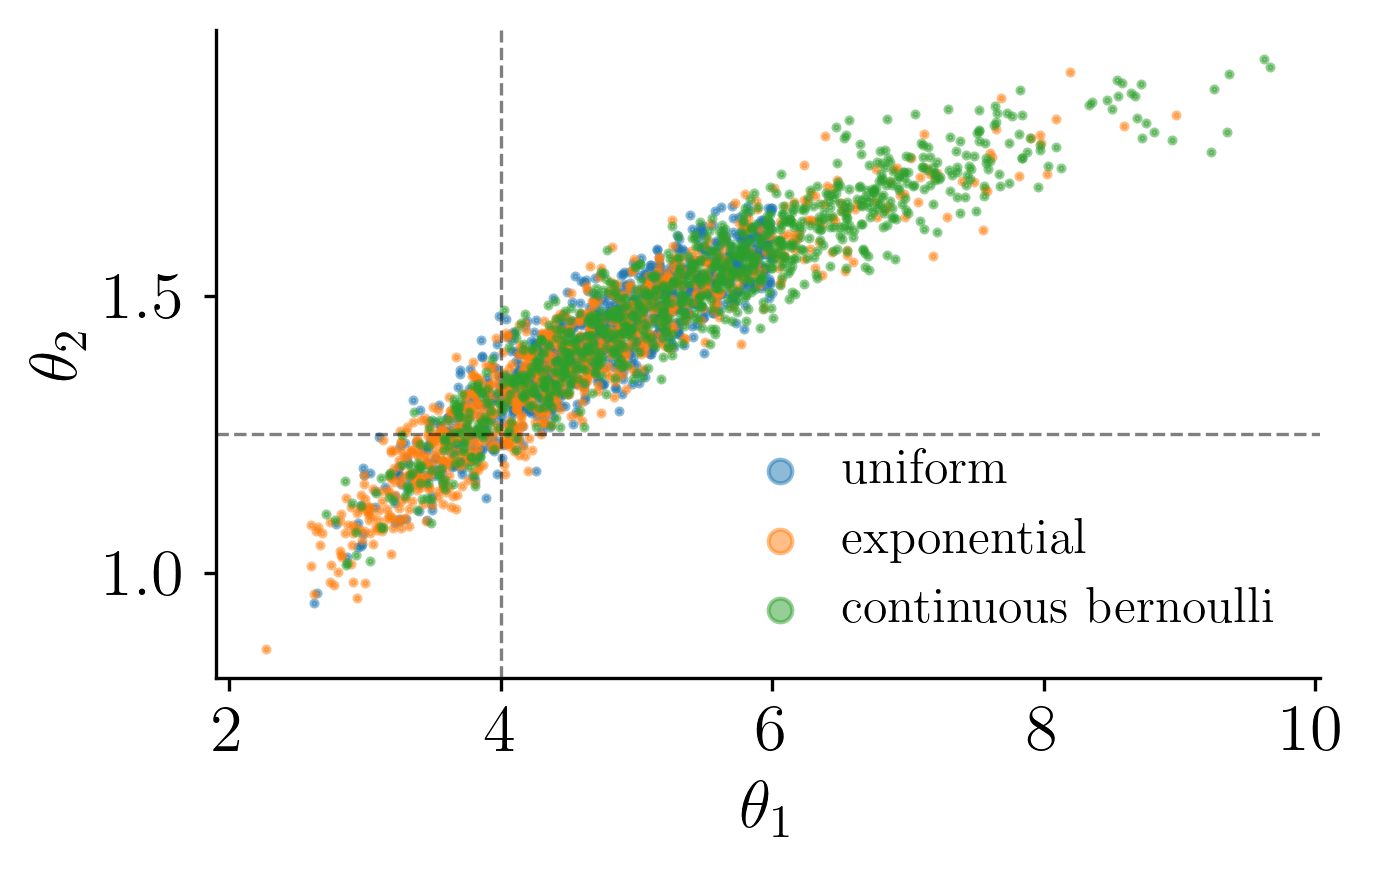

In [33]:
plot_cmp1d_lrm_prior_samples(
    results,
    thin=20,
    true_theta=(4.0, 1.25),
    figsize=(4.8, 3.),
)


#plt.savefig("./results/CMP-prior-comparison.pdf", format="pdf", bbox_inches='tight')

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def plot_cmp1d_lrm_prior_kde(
    results,
    transform=eta_to_theta_cmp1d,
    true_theta=None,
    figsize=(5.5, 4.5),
    gridsize=250,
    probs=(0.5, 0.8, 0.95),
    bw_method=0.4,
    linewidth=1.4,
    x_quantiles=(0.001, 0.999),
    y_quantiles=(0.001, 0.999),
):
    """
    Plot smooth KDE highest-density contours for CMP1D posterior samples.

    The contours correspond approximately to posterior mass levels given by
    probs, e.g. probs=(0.5, 0.8, 0.95).
    """

    fig, ax = plt.subplots(figsize=figsize)

    processed = {}

    for prior_name, out in results.items():
        samples = np.asarray(out["samples"], dtype=float)

        if transform is not None:
            samples = transform(samples)

        if samples.ndim != 2 or samples.shape[1] != 2:
            raise ValueError(
                f"Expected samples for {prior_name} to have shape (n_samples, 2)."
            )

        samples = samples[np.isfinite(samples).all(axis=1)]

        if samples.shape[0] < 10:
            raise ValueError(f"Too few finite samples for {prior_name}.")

        processed[prior_name] = samples

    all_samples = np.vstack(list(processed.values()))

    x_min, x_max = np.quantile(all_samples[:, 0], x_quantiles)
    y_min, y_max = np.quantile(all_samples[:, 1], y_quantiles)

    x_pad = 0.08 * (x_max - x_min)
    y_pad = 0.08 * (y_max - y_min)

    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, gridsize)
    y_grid = np.linspace(y_min - y_pad, y_max + y_pad, gridsize)

    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.vstack([X.ravel(), Y.ravel()])

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    legend_handles = []

    for i, (prior_name, samples) in enumerate(processed.items()):
        color = colors[i % len(colors)]

        kde = gaussian_kde(samples.T, bw_method=bw_method)

        Z = kde(grid_points).reshape(X.shape)

        # Evaluate KDE at the posterior samples.
        # These values are used to define highest-density credible contours.
        sample_density = kde(samples.T)

        # For a p credible contour, threshold density is the (1-p)-quantile
        # of the density values at the samples.
        contour_levels = [
            np.quantile(sample_density, 1.0 - p)
            for p in probs
        ]

        # Matplotlib needs levels increasing.
        contour_levels = np.sort(contour_levels)

        ax.contour(
            X,
            Y,
            Z,
            levels=contour_levels,
            colors=[color],
            linewidths=linewidth,
            alpha=0.95,
        )

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linewidth=linewidth,
                label=prior_name,
            )
        )

    if true_theta is not None:
        ax.axvline(
            true_theta[0],
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
        )
        ax.axhline(
            true_theta[1],
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
        )

    ax.set_xlabel(r"$\theta_1$", fontsize=16)
    ax.set_ylabel(r"$\theta_2$", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=16,
        handletextpad=0.4,
        loc='lower right',
    )

    plt.tight_layout()

    return fig, ax

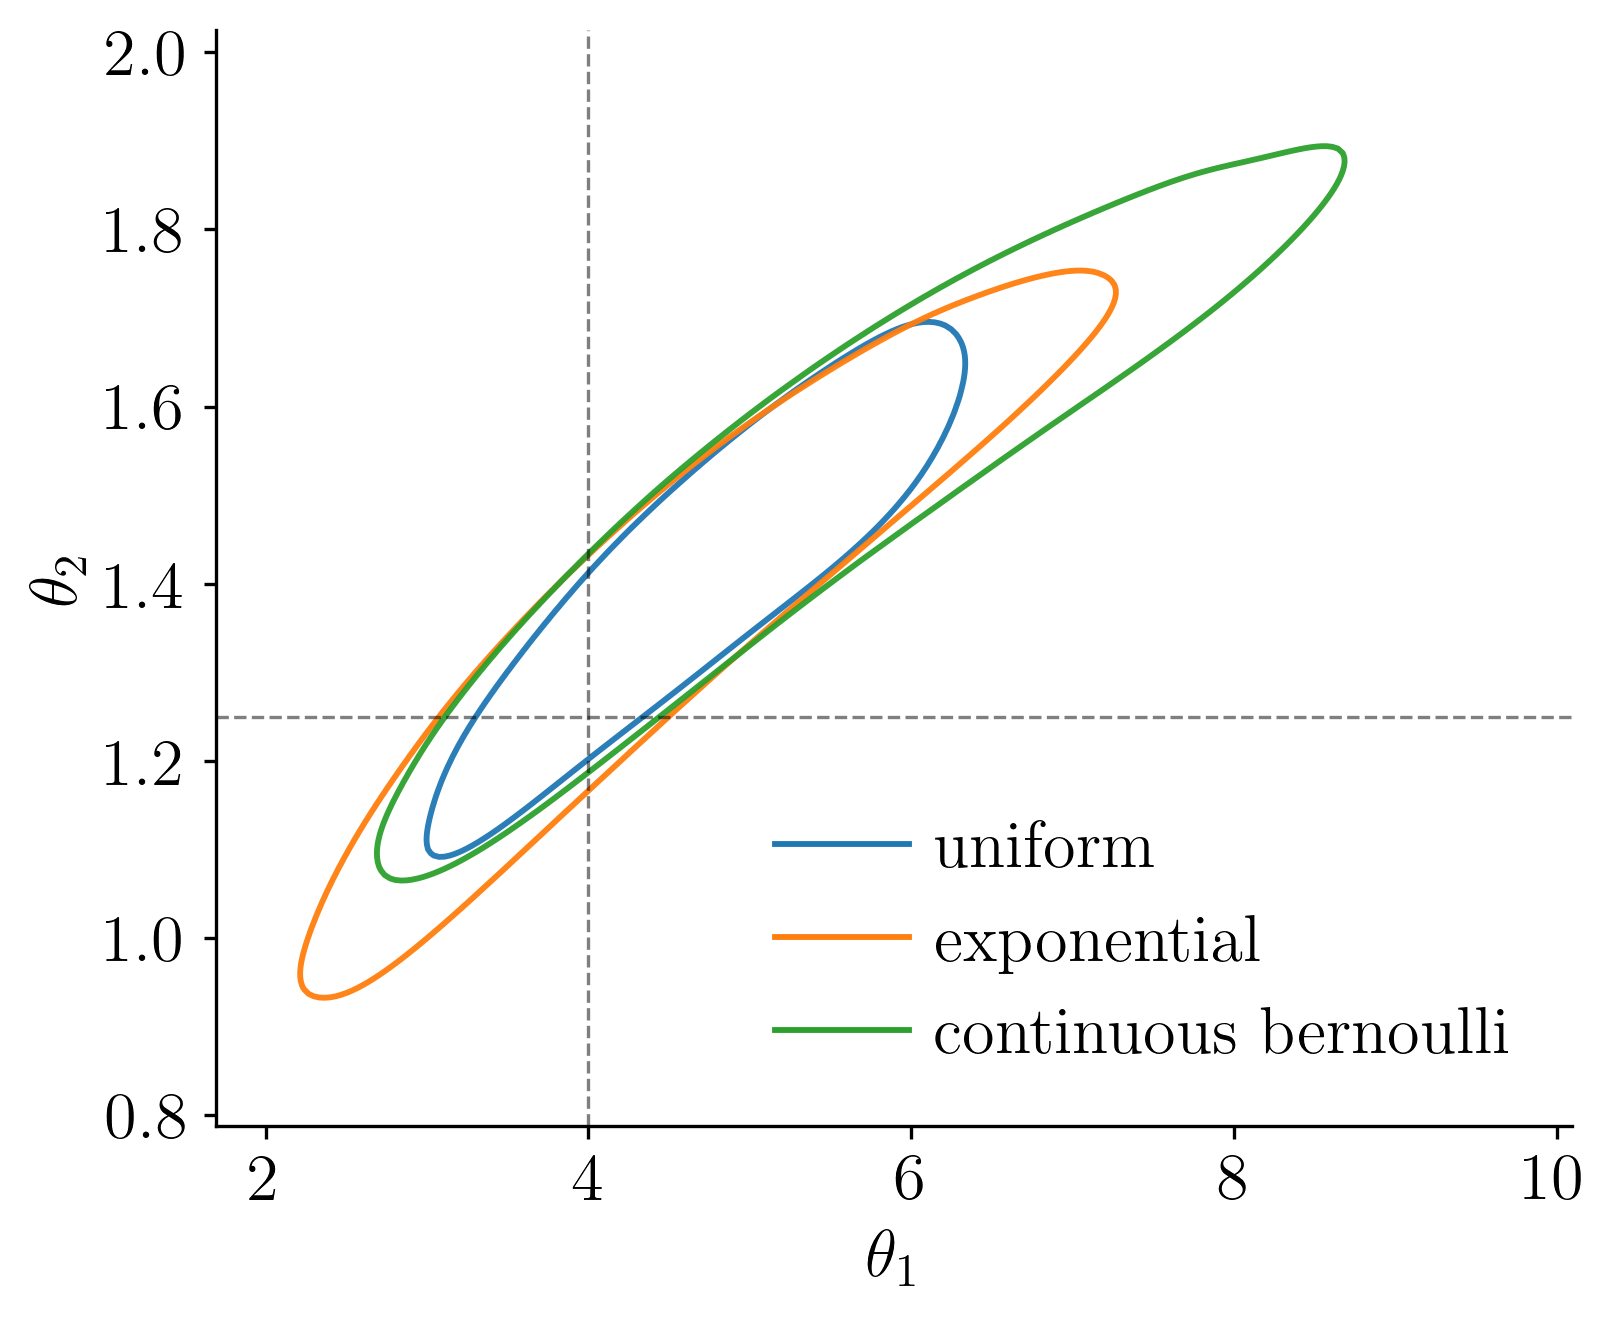

In [39]:
fig, ax = plot_cmp1d_lrm_prior_kde(
    results,
    true_theta=(4.0, 1.25),
    probs=(0.95,),
    bw_method=0.4,
)
plt.savefig("./results/CMP-prior-comparison-small-n-kde.pdf", format="pdf", bbox_inches='tight')